In [13]:
#Required Lib

In [14]:
# !pip install python-docx
# !pip install PyPDF2
import os # operating system for file path
import re   #Regular Wxpression for data cleaning luke hashtags all symbols
import pandas as pd #preprocessing
from docx import Document
import PyPDF2

In [15]:
import zipfile
zip_path = "D:\Chandana DataScience\PROJECT\P647-Resume Classification\Resumes-20230901T040204Z-001 (1).zip"
extract_path = r"D:\Chandana DataScience\PROJECT\P647-Resume Classification\resumesss"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
    print("Extraction completed.")

Extraction completed.


In [16]:
base_path = r"D:\Chandana DataScience\PROJECT\P647-Resume Classification\resumesss\Resumes"

In [17]:
for folder in os.listdir(base_path):
    print(folder)

Internship_Ravali_Musquare Technologies (1).docx
Internship_Susovan Bag_Musquare Technologies.docx
Peoplesoft resumes
React Developer_Deepakreddy.docx
React Developer_Haripriya.docx
React Developer_Kamalakar Reddy.docx
React Developer_Naveen sadhu.docx
React Developer_PavasGoswami.doc
React Developer_Pragnya.docx
React Developer_Sarala Madasu-converted.docx
React Developer_Thirupathiamma.docx
React Developer_Vinay Reddy.doc
React Dev_Krishna Kanth.docx
React Dev_Krishna Kanth_Musquare Technologies.docx
React JS Developer_AnjaniPriyadarshini.doc
React JS Developer_KotaniDurgaprasad[3_1] (1)-converted.docx
React JS Developer_Venkatalakshmi (1)-converted.docx
Reactjs Developer_kambala sai surendra_Musquare Technologies.docx
Reactjs Developer_M Lokesh Babu_Musquare Technologies.docx
Reactjs Developer_M Lokesh.docx
Reactjs Developer_MD Khizaruddin Rauf _Musquare Technologies.docx
Reactjs Developer_Prabakaran_Musquare Technologies.pdf
Reactjs Developer_Pranish Sonone_Musquare Technologies.do

In [18]:
data = []  #convert document into data frame

for root, dirs, files in os.walk(base_path):
    for file in files:
        file_path = os.path.join(root, file)
        category = os.path.basename(root)   # folder name = label

        data.append([file_path, category])

In [19]:
df = pd.DataFrame(data, columns=["file_path", "category"])
df

,file_path,category
0,D:\Chandana DataScience\PROJECT\P647-Resume Cl...,Resumes
1,D:\Chandana DataScience\PROJECT\P647-Resume Cl...,Resumes
2,D:\Chandana DataScience\PROJECT\P647-Resume Cl...,Resumes
3,D:\Chandana DataScience\PROJECT\P647-Resume Cl...,Resumes
4,D:\Chandana DataScience\PROJECT\P647-Resume Cl...,Resumes
...,...,...
74,D:\Chandana DataScience\PROJECT\P647-Resume Cl...,workday resumes
75,D:\Chandana DataScience\PROJECT\P647-Resume Cl...,workday resumes
76,D:\Chandana DataScience\PROJECT\P647-Resume Cl...,workday resumes
77,D:\Chandana DataScience\PROJECT\P647-Resume Cl...,workday resumes


In [20]:
print("Total resumes:", len(df))

Total resumes: 79


In [21]:
!pip install python-docx


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\sreej\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [22]:
from docx import Document    #basic EDA min mode median

def read_resume(file_path):
    try:
        doc = Document(file_path)
        text = []
        for para in doc.paragraphs:
            text.append(para.text)
        return " ".join(text)
    except:
        return ""

In [23]:
df["resume_text"] = df["file_path"].apply(read_resume)

# EDA

In [24]:
df["text_length"] = df["resume_text"].apply(len)
df["text_length"].describe()

count       79.000000
mean      2657.632911
std       2733.681101
min          0.000000
25%          0.000000
50%       2609.000000
75%       3976.000000
max      15339.000000
Name: text_length, dtype: float64

In [25]:
df.shape

(79, 4)

In [26]:
df.columns

Index(['file_path', 'category', 'resume_text', 'text_length'], dtype='object')

In [27]:
# Checking Null values
df.isnull().sum()

file_path      0
category       0
resume_text    0
text_length    0
dtype: int64

In [28]:
# Checking Duplicate values
print("Duplicates:", df.duplicated(subset="resume_text").sum())

Duplicates: 26


In [29]:
df["category"].value_counts()

category
Resumes                            24
workday resumes                    21
Peoplesoft resumes                 20
SQL Developer Lightning insight    14
Name: count, dtype: int64

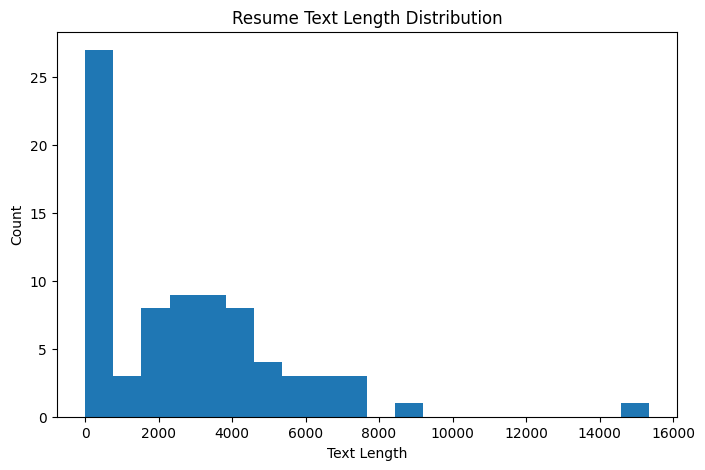

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["text_length"], bins=20)
plt.title("Resume Text Length Distribution")
plt.xlabel("Text Length")
plt.ylabel("Count")
plt.show()

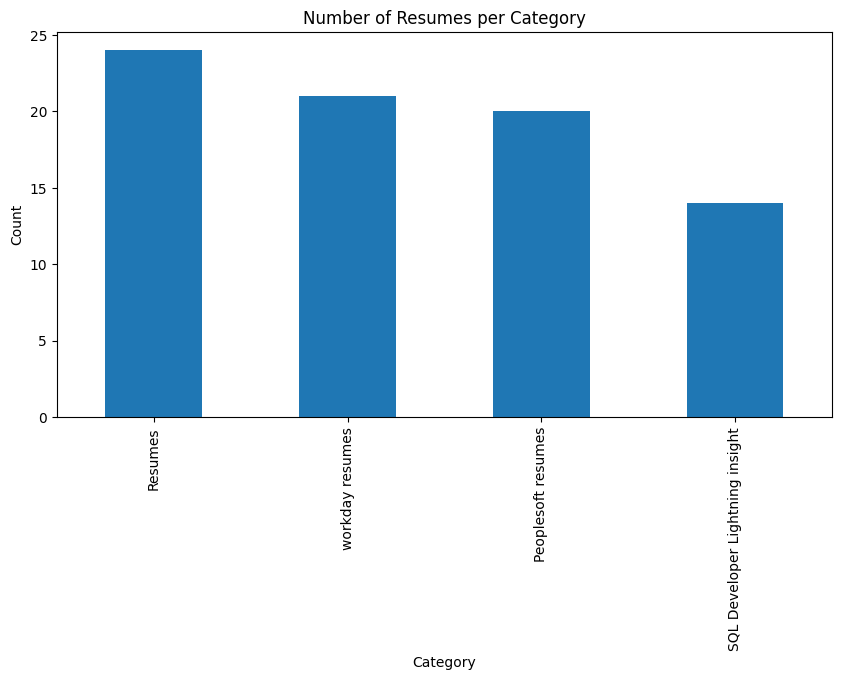

In [31]:
plt.figure(figsize=(10,5))
df["category"].value_counts().plot(kind="bar")
plt.title("Number of Resumes per Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

# Data Cleaning

In [32]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")    # Remove stop words meaning less words
stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sreej\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [33]:
def clean_resume(text): # clean all data

    text = str(text).lower()

    # remove urls
    text = re.sub(r"http\S+|www\S+", "", text)

    # remove emails
    text = re.sub(r"\S+@\S+", "", text)

    # remove numbers
    text = re.sub(r"\d+", "", text)

    # remove special characters
    text = re.sub(r"[^a-zA-Z ]", " ", text)

    # remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [34]:
df["cleaned_text"] = df["resume_text"].apply(clean_resume)

In [35]:
df[["resume_text","cleaned_text"]].head()

,resume_text,cleaned_text
0,Name: Ravali P ...,name ravali p curriculum vitae specialization ...
1,SUSOVAN BAG Seeking a challenging po...,susovan bag seeking challenging position field...
2,Kanumuru Deepak Reddy CAREER OBJECTIVE: To...,kanumuru deepak reddy career objective secure ...
3,HARIPRIYA BATTINA Experience as UI Developer ...,haripriya battina experience ui developer reac...
4,KAMALAKAR REDDY. A Linked In: https://www.lin...,kamalakar reddy linked professional summary ye...


In [36]:
# Word Frequency Analysis
from collections import Counter #repeted word count

all_words = " ".join(df["cleaned_text"]).split()

word_freq = Counter(all_words)
word_freq.most_common(20)

[('experience', 309),
 ('using', 241),
 ('workday', 194),
 ('application', 186),
 ('sql', 178),
 ('project', 168),
 ('server', 168),
 ('data', 167),
 ('reports', 164),
 ('business', 156),
 ('peoplesoft', 156),
 ('knowledge', 129),
 ('web', 125),
 ('process', 120),
 ('react', 116),
 ('good', 103),
 ('skills', 100),
 ('system', 96),
 ('working', 96),
 ('involved', 96)]

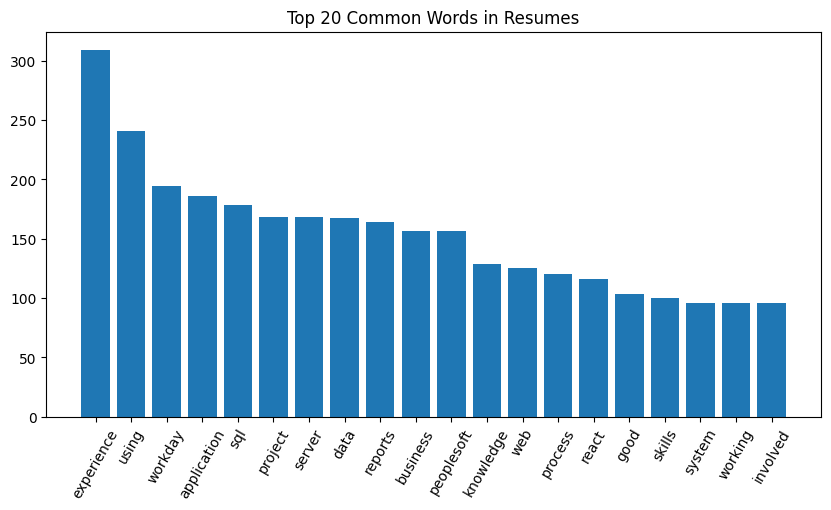

In [37]:
common_words = word_freq.most_common(20)  #common wors

words = [i[0] for i in common_words]
counts = [i[1] for i in common_words]

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.xticks(rotation=60)
plt.title("Top 20 Common Words in Resumes")
plt.show()

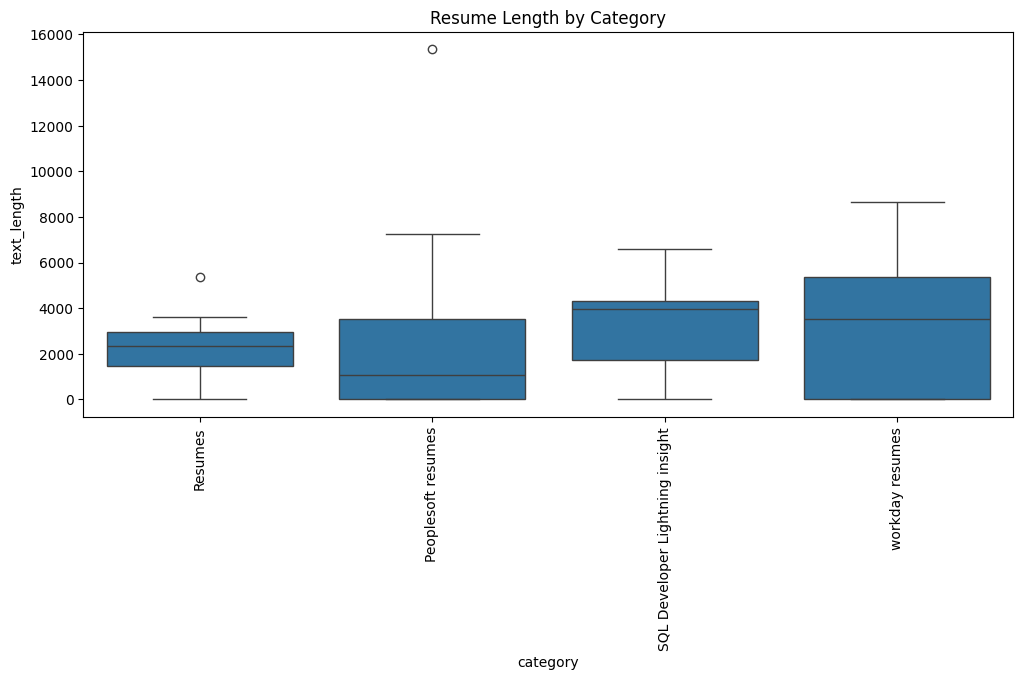

In [38]:
import seaborn as sns
plt.figure(figsize=(12,5))
sns.boxplot(x="category", y="text_length", data=df)
plt.xticks(rotation=90)
plt.title("Resume Length by Category")
plt.show()

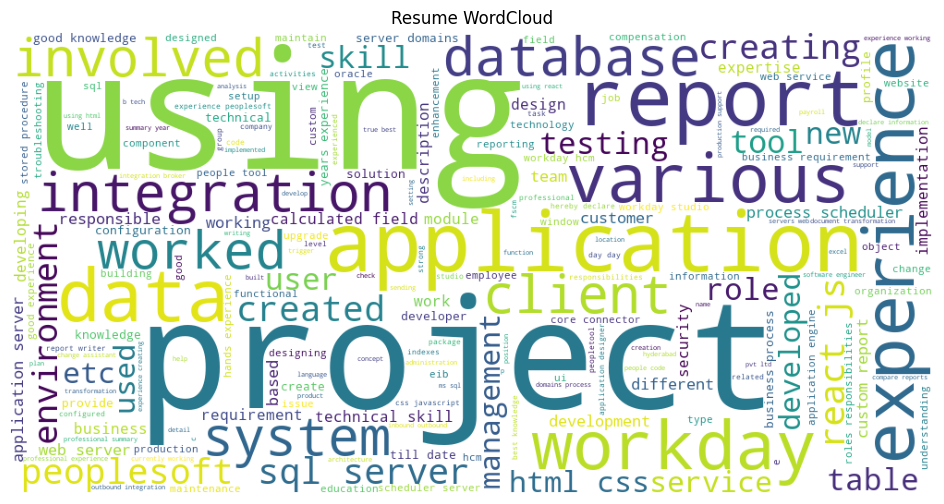

In [39]:
from wordcloud import WordCloud

text = " ".join(df["cleaned_text"])

wordcloud = WordCloud(width=1000, height=500, background_color="white").generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Resume WordCloud")
plt.show()

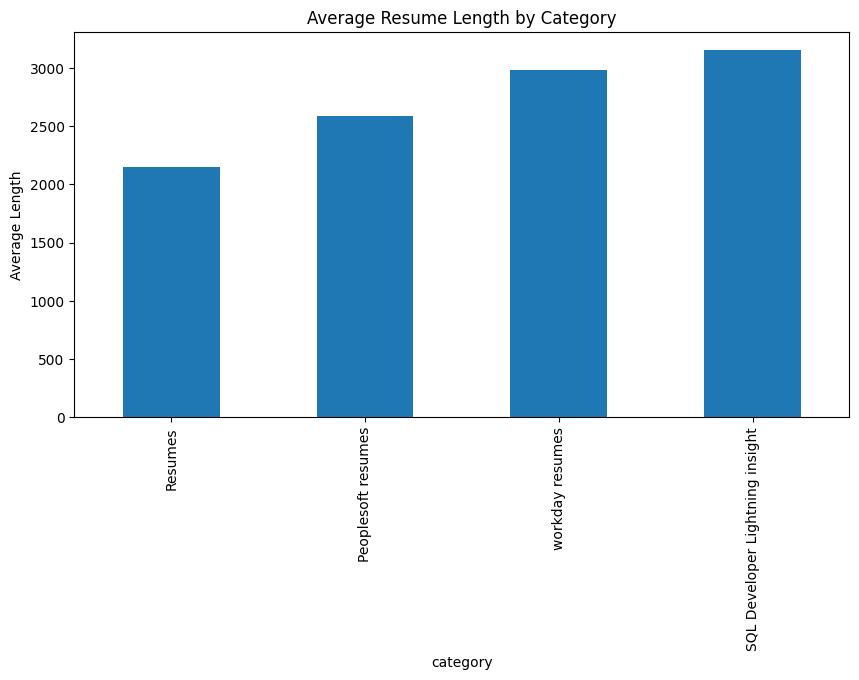

In [40]:
df.groupby("category")["text_length"].mean().sort_values().plot(kind="bar", figsize=(10,5))
plt.title("Average Resume Length by Category")
plt.ylabel("Average Length")
plt.show()

In [41]:
df["cleaned_text"]

0     name ravali p curriculum vitae specialization ...
1     susovan bag seeking challenging position field...
2     kanumuru deepak reddy career objective secure ...
3     haripriya battina experience ui developer reac...
4     kamalakar reddy linked professional summary ye...
                            ...                        
74                                                     
75    seeking suitable positions workday hcm techno ...
76    workday hcm fcm name kumar role workday consul...
77                                                     
78    vinay kumar v workday functional consultant ex...
Name: cleaned_text, Length: 79, dtype: object

In [42]:
df = df[df["cleaned_text"].str.len() > 0]


In [43]:
df

,file_path,category,resume_text,text_length,cleaned_text
0,D:\Chandana DataScience\PROJECT\P647-Resume Cl...,Resumes,Name: Ravali P ...,3498,name ravali p curriculum vitae specialization ...
1,D:\Chandana DataScience\PROJECT\P647-Resume Cl...,Resumes,SUSOVAN BAG Seeking a challenging po...,1667,susovan bag seeking challenging position field...
2,D:\Chandana DataScience\PROJECT\P647-Resume Cl...,Resumes,Kanumuru Deepak Reddy CAREER OBJECTIVE: To...,3547,kanumuru deepak reddy career objective secure ...
3,D:\Chandana DataScience\PROJECT\P647-Resume Cl...,Resumes,HARIPRIYA BATTINA Experience as UI Developer ...,2627,haripriya battina experience ui developer reac...
4,D:\Chandana DataScience\PROJECT\P647-Resume Cl...,Resumes,KAMALAKAR REDDY. A Linked In: https://www.lin...,2621,kamalakar reddy linked professional summary ye...
5,D:\Chandana DataScience\PROJECT\P647-Resume Cl...,Resumes,Naveen Sadhu Title: software developer\t\t\...,1450,naveen sadhu title software developer location...
7,D:\Chandana DataScience\PROJECT\P647-Resume Cl...,Resumes,PRAGNYA PATTNAIK Expertise: Having...,2609,pragnya pattnaik expertise around years experi...
8,D:\Chandana DataScience\PROJECT\P647-Resume Cl...,Resumes," 204,Sri geethika prestige,road number 10,b...",2542,sri geethika prestige road number bandari layo...
9,D:\Chandana DataScience\PROJECT\P647-Resume Cl...,Resumes,\n Thirupathamma Balla SUMMARY: 2.8 year of ...,994,thirupathamma balla summary year experience re...
11,D:\Chandana DataScience\PROJECT\P647-Resume Cl...,Resumes,Ui-Developer/ React JS Developer NAME: KRISH...,3633,ui developer react js developer name krishna p...


In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000,ngram_range=(1,2))
X = tfidf.fit_transform(df["cleaned_text"])

In [45]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report

In [46]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df['category'])

for rs in [0, 21, 42, 99]:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=rs)

In [47]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import precision_recall_fscore_support

In [48]:
# Logistic Regression
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9090909090909091
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.67      1.00      0.80         2
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00         2

    accuracy                           0.91        11
   macro avg       0.92      0.92      0.90        11
weighted avg       0.94      0.91      0.91        11



In [49]:
# Naive Bayes
model_nb = MultinomialNB()
model_nb.fit(X_train, y_train)

y_pred_nb = model_nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.7272727272727273
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.40      1.00      0.57         2
           2       1.00      0.50      0.67         4
           3       1.00      1.00      1.00         2

    accuracy                           0.73        11
   macro avg       0.85      0.79      0.76        11
weighted avg       0.89      0.73      0.75        11



In [50]:
# SVM
model_svm = LinearSVC()
model_svm.fit(X_train, y_train)

y_pred_svm = model_svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00         2

    accuracy                           1.00        11
   macro avg       1.00      1.00      1.00        11
weighted avg       1.00      1.00      1.00        11



In [51]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00         2

    accuracy                           1.00        11
   macro avg       1.00      1.00      1.00        11
weighted avg       1.00      1.00      1.00        11



In [52]:
#XGBoost
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00         2

    accuracy                           1.00        11
   macro avg       1.00      1.00      1.00        11
weighted avg       1.00      1.00      1.00        11



In [53]:
results = {
    "Model": ["Logistic Regression", "Naive Bayes", "SVM", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "precision":[
        precision_score(y_test, y_pred_lr, average='weighted'),
        precision_score(y_test, y_pred_nb, average='weighted'),
        precision_score(y_test, y_pred_svm, average='weighted'),
        precision_score(y_test, y_pred_rf, average='weighted'),
        precision_score(y_test, y_pred_xgb, average='weighted')],
    "recall":[
        recall_score(y_test, y_pred_lr, average='weighted'),
        recall_score(y_test, y_pred_nb, average='weighted'),
        recall_score(y_test, y_pred_svm, average='weighted'),
        recall_score(y_test, y_pred_rf, average='weighted'),
        recall_score(y_test, y_pred_xgb, average='weighted')],
    "F1-Score":[
        f1_score(y_test, y_pred_lr, average='weighted'),
        f1_score(y_test, y_pred_nb, average='weighted'),
        f1_score(y_test, y_pred_svm, average='weighted'),
        f1_score(y_test, y_pred_rf, average='weighted'),
        f1_score(y_test, y_pred_xgb, average='weighted')],
    "support":[
        precision_recall_fscore_support(y_test, y_pred_lr, average='weighted'),
        precision_recall_fscore_support(y_test, y_pred_nb, average='weighted'),
        precision_recall_fscore_support(y_test, y_pred_svm, average='weighted'),
        precision_recall_fscore_support(y_test, y_pred_rf, average='weighted'),
        precision_recall_fscore_support(y_test, y_pred_xgb, average='weighted')]
    
}

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,precision,recall,F1-Score,support
0,Logistic Regression,0.909091,0.939394,0.909091,0.909091,"(0.9393939393939393, 0.9090909090909091, 0.909..."
1,Naive Bayes,0.727273,0.890909,0.727273,0.746320,"(0.890909090909091, 0.7272727272727273, 0.7463..."
2,SVM,1.000000,1.000000,1.000000,1.000000,"(1.0, 1.0, 1.0, None)"
3,Random Forest,1.000000,1.000000,1.000000,1.000000,"(1.0, 1.0, 1.0, None)"
4,XGBoost,1.000000,1.000000,1.000000,1.000000,"(1.0, 1.0, 1.0, None)"


In [54]:
results_df["Combined_Score"] = (
    results_df["Accuracy"] +
    results_df["precision"] +
    results_df["recall"] +
    results_df["F1-Score"]
) / 4

best_model = results_df.loc[results_df["Combined_Score"].idxmax()]

print(best_model)

Model                               SVM
Accuracy                            1.0
precision                           1.0
recall                              1.0
F1-Score                            1.0
support           (1.0, 1.0, 1.0, None)
Combined_Score                      1.0
Name: 2, dtype: object
